In [1]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [2]:
torch.cuda.is_available()

True

In [3]:
torch.cuda.get_device_name()

'NVIDIA A100-PCIE-40GB MIG 3g.20gb'

In [4]:
torch.cuda.device_count()

1

In [5]:
print(torch.cuda.mem_get_info())  # (free, total)

(20707147776, 20937965568)


In [6]:
#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/transformers
#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/transformers-*.dist-info

#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/torch
#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/torch-*.dist-info

#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/bacformer
#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/bacformer-*.dist-info

In [6]:
!/shared/software/miniconda/envs/python-3.12/bin/python -m pip install --no-cache-dir "transformers==4.57.5" bacformer

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import transformers, torch
print("transformers:", transformers.__version__)
print("transformers path:", transformers.__file__)
print("torch path:", torch.__file__)
from transformers import PreTrainedModel

transformers: 4.57.5
transformers path: /shared/home/myoussef/.local/lib/python3.12/site-packages/transformers/__init__.py
torch path: /shared/software/miniconda/envs/python-3.12/lib/python3.12/site-packages/torch/__init__.py


In [8]:
print(torch.__version__)
print(transformers.__version__)

2.6.0
4.57.5


In [9]:
import os, gzip
from pathlib import Path
from collections import Counter, defaultdict
import glob

import numpy as np
import pandas as pd
from Bio import SeqIO

#import torch
from transformers import AutoModel
from bacformer.pp import protein_seqs_to_bacformer_inputs
#from bacformer.modeling import SPECIAL_TOKENS_DICT

In [11]:
# bacformer/pp/preprocess.py
# chnagement de extract_protein_info_from_genbank() et preprocess_genome_assembly()

import gzip
from typing import Any

import pandas as pd
from Bio import SeqIO


def extract_protein_info_from_genbank(filepath: str):
    """
    Extract protein details from a GenBank file (.gbff/.gbk and optionally .gz) and return a DataFrame.

    Returns a DataFrame with columns used by Bacformer preprocessing.
    """
    if filepath.endswith(".gz"):
        handle = gzip.open(filepath, "rt")
    else:
        handle = open(filepath, "r")

    records = SeqIO.parse(handle, "genbank")
    data = []

    contig_idx = 0
    for record in records:
        genome_name = record.annotations.get("organism", None)

        for feature in record.features:
            if feature.type != "CDS":
                continue

            translation = feature.qualifiers.get("translation", [None])[0]
            if translation is None:
                continue

            gene_name = feature.qualifiers.get("gene", [None])[0]
            locus_tag = feature.qualifiers.get("locus_tag", [None])[0]
            protein_id = feature.qualifiers.get("protein_id", [None])[0]

            start = int(feature.location.start)
            end = int(feature.location.end)

            data.append(
                {
                    "strain_name": genome_name,
                    "gene_name": gene_name,
                    "protein_name": locus_tag,
                    "start": start,
                    "end": end,
                    "protein_id": protein_id,
                    "contig_idx": contig_idx,
                    "protein_sequence": translation,
                }
            )

        contig_idx += 1

    handle.close()
    return pd.DataFrame(data)

def extract_protein_info_from_gff(filepath):
    """
    Extract protein details from a GFF file (.gff or .gff.gz) into a pandas DataFrame.

    Args:
        filepath (str): Path to the GFF file.

    Returns
    -------
        pd.DataFrame: A DataFrame where each row is a gene, with columns for gene details.
    """
    genes = []

    # Open the file based on its extension
    if filepath.endswith(".gz"):
        open_func = gzip.open
        mode = "rt"  # Read as text
    else:
        open_func = open
        mode = "r"

    with open_func(filepath, mode) as file:
        for line in file:
            if line.startswith("#"):
                # # Extract assembly ID from the header
                # if line.startswith("##sequence-region"):
                #     assembly_id = line.split()[1]
                continue

            parts = line.strip().split("\t")
            if len(parts) < 9:
                continue  # Skip malformed lines

            feature_type = parts[2]
            if feature_type != "CDS":
                continue  # Focus only on genes

            seqid = parts[0]
            start = int(parts[3])
            end = int(parts[4])
            strand = parts[6]
            attributes = parts[8]

            # Parse attributes
            attr_dict = {}
            for attr in attributes.split(";"):
                if "=" in attr:
                    key, value = attr.split("=", 1)
                    attr_dict[key] = value

            # Extract specific fields
            gene_name = attr_dict.get("gene", None)
            locus_tag = attr_dict.get("locus_tag", None)
            protein_id = attr_dict.get("protein_id", None)

            # Append gene info to the list
            genes.append(
                {
                    "seqid": seqid,
                    "start": start,
                    "end": end,
                    "strand": strand,
                    "gene_name": gene_name if gene_name is not None else locus_tag,
                    "locus_tag": locus_tag,
                    "protein_id": protein_id,
                }
            )

    # Convert to DataFrame
    df = pd.DataFrame(genes)
    return df

def preprocess_genome_assembly(filepath: str) -> dict[str, Any]:
    """
    Preprocess a genome assembly file (GenBank or GFF) to extract protein information for Bacformer input.
    Modified: does NOT rely on accession fields; accepts .gbk/.gbk.gz too.
    """
    if filepath.endswith((".gbff", ".gbff.gz", ".gbk", ".gbk.gz")):
        df = extract_protein_info_from_genbank(filepath)
    elif filepath.endswith((".gff", ".gff.gz")):
        df = extract_protein_info_from_gff(filepath)
    else:
        raise ValueError("Unsupported file format. Use .gbff/.gbk or .gff (optionally .gz).")

    if df.empty:
        raise ValueError("No protein translations found in file (empty CDS/translation set).")

    # groupby contig and aggregate protein information
    df = (
        df.groupby(["strain_name", "contig_idx"])[
            ["gene_name", "protein_name", "start", "end", "protein_id", "protein_sequence"]
        ]
        .agg(list)
        .reset_index()
    )

    # sort by contig_idx
    df = df.sort_values(by="contig_idx", ascending=True)

    # aggregate all contigs in the genome
    df = (
        df.groupby(["strain_name"])[
            ["contig_idx", "gene_name", "protein_name", "start", "end", "protein_id", "protein_sequence"]
        ]
        .agg(list)
        .reset_index()
    )

    return dict(df.iloc[0])

In [12]:
INPUT_DIR = "genomes_gbff"
OUT_DIR = "embeddings_out"
os.makedirs(OUT_DIR, exist_ok=True)

device = "cuda:0" #if torch.cuda.is_available() else "cpu"

# --------- Charger le modèle une fois ---------
model = AutoModel.from_pretrained(
    "macwiatrak/bacformer-masked-complete-genomes", trust_remote_code=True
).to(device).eval().to(torch.bfloat16)

# --------- Petite fonction: vérifier que le .pt existe et est OK ---------
def output_is_valid(out_path: str) -> bool:
    """Retourne True si le fichier .pt existe et semble lisible/valide."""
    if not os.path.isfile(out_path):
        return False
    try:
        obj = torch.load(out_path)
        # check minimal: présence et type/shape
        if "last_hidden_state" not in obj:
            return False
        t = obj["last_hidden_state"]
        if not torch.is_tensor(t):
            return False
        if t.ndim != 3:
            return False
        return True
    except Exception:
        return False

# --------- Boucle sur les fichiers GenBank ---------
files = sorted(glob.glob(os.path.join(INPUT_DIR, "*.gbff")))
print("Nb fichiers:", len(files))

for fp in files:
    genome_id = os.path.splitext(os.path.basename(fp))[0]
    
    # >>> AJOUT: vérifier si déjà généré
    out_path = os.path.join(OUT_DIR, f"{genome_id}.pt")
    if output_is_valid(out_path):
        print("Skipping (already done):", genome_id)
        continue
    # <<< FIN AJOUT
    
    print("Processing:", genome_id)

    # 1) Pré-traitement genome -> protéines
    genome_info = preprocess_genome_assembly(filepath=fp)
    protein_seqs = genome_info["protein_sequence"]

    # 2) Préparer inputs (calcule d'abord des embeddings protéines via un PLM, puis format Bacformer)
    inputs = protein_seqs_to_bacformer_inputs(
        protein_seqs,
        device=device,
        batch_size=128,
        max_n_proteins=6000,
    )

    # 3) Bacformer: embeddings contextualisés
    with torch.no_grad():
        outputs = model(**inputs, return_dict=True)

    last_hidden = outputs["last_hidden_state"]  # (1, seq_len, dim)
    # Pour un "genome embedding" par moyenne de seq_len
    #genome_emb = last_hidden.mean(dim=1)

    # 4) Sauvegarde simple
    #out_path = os.path.join(OUT_DIR, f"{genome_id}.pt")
    torch.save(
        {
            "genome_id": genome_id,
            "n_proteins": len(protein_seqs),
            "last_hidden_state": last_hidden.cpu(),  # embeddings contextualisés
            #"genome_embedding_mean": genome_emb.cpu(),
        },
        out_path,
    )

    print("  saved:", out_path, "| last_hidden_state:", tuple(last_hidden.shape))

Nb fichiers: 1066
Skipping (already done): 1328432.3
Skipping (already done): 1328433.3
Skipping (already done): 1328434.3
Skipping (already done): 1328436.3
Skipping (already done): 1328437.3
Skipping (already done): 1328438.3
Skipping (already done): 1328439.3
Skipping (already done): 1328440.3
Skipping (already done): 1328441.3
Skipping (already done): 1328442.3
Skipping (already done): 1328443.3
Skipping (already done): 1328444.3
Skipping (already done): 1328445.3
Skipping (already done): 1328446.3
Skipping (already done): 1328447.3
Skipping (already done): 1328448.3
Skipping (already done): 1328449.3
Skipping (already done): 1328450.3
Skipping (already done): 1400156.3
Skipping (already done): 1400157.3
Skipping (already done): 1400158.3
Skipping (already done): 1416670.3
Skipping (already done): 1416671.3
Skipping (already done): 1416672.3
Skipping (already done): 1416673.3
Skipping (already done): 1416674.4
Skipping (already done): 1416675.3
Skipping (already done): 1438668.3
Sk

In [10]:
x = torch.load("./embeddings_out/562.90695.pt")["last_hidden_state"]
print(x[0, :7, :7])  # 5 protéines/tokens × 5 dimensions

tensor([[ 0.1187,  0.2168, -0.1099,  0.1641, -0.1216,  0.0041, -0.4629],
        [-0.0398,  0.3574,  0.1108,  0.2812, -0.0366,  0.2119, -0.3711],
        [ 0.0820,  0.2080,  0.0184,  0.3359, -0.3223, -0.1348, -0.3984],
        [-0.1787,  0.1357,  0.1641,  0.3691, -0.2559,  0.0439, -0.0371],
        [-0.0199,  0.1318, -0.0327,  0.1455, -0.1025,  0.4668, -0.2773],
        [ 0.1914,  0.2812, -0.4375, -0.0884,  0.0767,  0.4609, -0.2012],
        [ 0.2363,  0.0918, -0.2354, -0.0442,  0.2256,  0.1846, -0.0081]],
       dtype=torch.bfloat16)


In [ ]:
import os
import glob
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

In [18]:
# Hyperparameters

PT_DIR = "embeddings_out"  
LABELS_PATH = "matrice_listantibio_final.cleaned.list"

SEED = 42
BATCH_SIZE = 8
EPOCHS = 25
LR = 3e-4
ATTN_DIM = 128
HIDDEN = 128   #for final classifier
DROPOUT = 0.3

SPLIT = (0.8, 0.1, 0.1)  # train/val/test
#MAX_PROTEINS = 6000 

device = "cuda" if torch.cuda.is_available() else "cpu"

# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Loding Labels

def load_labels(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    df["Resistant"] = df["Resistant"].astype(int)
    df["Susceptible"] = df["Susceptible"].astype(int)

    bad = df[(df["Resistant"] + df["Susceptible"]) != 1]
    if len(bad) > 0:
        print("Incoherent label rows (Resistant+Susceptible != 1):", len(bad))
        print(bad.head())
    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"]))


# Load ONE .PT -> (genome_id, X(P,D))

def load_pt(fp):
    obj = torch.load(fp)
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X = obj["last_hidden_state"]

    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)

    # expected: (1,P,D) or (P,D)
    if X.ndim == 3:
        X = X.squeeze(0)
    if X.ndim != 2:
        raise ValueError(f"{fp}: unexpected last_hidden_state shape {tuple(X.shape)}")

    #if X.shape[0] > MAX_PROTEINS:
        #X = X[:MAX_PROTEINS]

    return gid, X.float()


# DATASET (1 genome = 1 item)

class GenomeMILDataset(Dataset):
    def __init__(self, pt_dir, id_to_y):
        self.id_to_y = id_to_y
        self.files = sorted(glob.glob(os.path.join(pt_dir, "*.pt")))
        if len(self.files) == 0:
            raise ValueError(f"No .pt found in: {pt_dir}")

        kept = []
        missing = 0
        for fp in self.files:
            gid, _ = load_pt(fp)
            if gid in id_to_y:
                kept.append(fp)
            else:
                missing += 1

        self.files = kept
        print("PT files with labels:", len(self.files), "| missing labels:", missing)
        if len(self.files) == 0:
            raise ValueError("No .pt matched to labels. Likely genome_id mismatch.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fp = self.files[idx]
        gid, X = load_pt(fp)  # (P,D)
        y = float(self.id_to_y[gid])  # 0/1
        return X, torch.tensor(y, dtype=torch.float32), gid


# COLLATE: PAD + MASK

def mil_collate(batch):
    xs, ys, gids = zip(*batch)
    lens = [x.shape[0] for x in xs] #prot nbr
    D = xs[0].shape[1] #emb dim of prot
    Pmax = max(lens) #max nbr of prot in batch # padding based on this length

    Xpad = torch.zeros((len(xs), Pmax, D), dtype=torch.float32)   #(B, Pmax,D) #B=batch
    mask = torch.zeros((len(xs), Pmax), dtype=torch.float32)   #(B,Pmax)

    for i, x in enumerate(xs):
        P = x.shape[0]
        Xpad[i, :P] = x
        mask[i, :P] = 1.0   #Lors du softmax : Sans masque, le modèle pourrait attribuer du poids à des “fausses protéines” (les zéros du padding)

    y = torch.stack(list(ys), dim=0)  # (B,)  #ys:tuple de tenseur
    return Xpad, mask, y, list(gids)  #Xpad:les embeddings paddés  #mask:indique où c’est du vrai / padding  #y:labels


# GATED ATTENTION MIL MODEL

class GatedAttentionMIL(nn.Module):
    """
    X: (B,P,D), mask: (B,P)
    - computes attention weights alpha over proteins
    - pooled genome vector z = sum(alpha_i * x_i)
    - outputs genome logit (B,)
    """
    def __init__(self, emb_dim, attn_dim=128, hidden=128, dropout=0.2):
        super().__init__()
        self.drop = nn.Dropout(dropout)

        self.V = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Tanh())
        self.U = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Sigmoid())
        self.w = nn.Linear(attn_dim, 1)  # renvoie un score = une valeir par prot

        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1), #sort un logit (resistant/susceptible
        )

    def forward(self, X, mask):
        X = self.drop(X)  # (B,P,D)   #Dropout sur les embeddings : régularise, évite de trop dépendre de quelques dimensions/features
        A = self.w(self.V(X) * self.U(X)).squeeze(-1)  # (B,P)

        # ignore padding for softmax
        A = A.masked_fill(mask == 0, float("-inf"))  #empêche le softmax de donner du poids au padding
        alpha = torch.softmax(A, dim=1)  # (B,P) #poids d'attention

        z = torch.sum(X * alpha.unsqueeze(-1), dim=1)  # (B,D)  #pooling pondéré
        logit = self.classifier(z).squeeze(-1)         # (B,)  #Ce logit sera ensuite utilisé avec BCEWithLogitsLoss
        return logit, alpha


# METRICS + TRAIN/EVAL LOOPS

def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = None
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_prob)
    return {"acc": acc, "f1": f1, "auc": auc}


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_y = []
    all_prob = []
    total_loss = 0.0
    n_batches = 0

    for Xpad, mask, y, _ in loader:
        Xpad = Xpad.to(device)
        mask = mask.to(device)
        y = y.to(device)

        logits, _ = model(Xpad, mask)
        loss = criterion(logits, y)

        prob = torch.sigmoid(logits).detach().cpu().numpy()
        all_prob.append(prob)
        all_y.append(y.detach().cpu().numpy())

        total_loss += float(loss.item())
        n_batches += 1

    y_true = np.concatenate(all_y, axis=0)
    y_prob = np.concatenate(all_prob, axis=0)
    m = compute_metrics(y_true, y_prob)
    m["loss"] = total_loss / max(n_batches, 1)
    return m


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for Xpad, mask, y, _ in loader:
        Xpad = Xpad.to(device)
        mask = mask.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits, _ = model(Xpad, mask)
        loss = criterion(logits, y) #compare prédictions vs y
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        n_batches += 1

    return total_loss / max(n_batches, 1)


### MAIN ###

set_seed(SEED)

id_to_y = load_labels(LABELS_PATH)
dataset = GenomeMILDataset(PT_DIR, id_to_y)

# Split indices
n = len(dataset)
idx = np.random.permutation(n)

n_train = int(SPLIT[0] * n)
n_val = int(SPLIT[1] * n)
train_idx = idx[:n_train]
val_idx = idx[n_train:n_train + n_val]
test_idx = idx[n_train + n_val:]

train_ds = Subset(dataset, train_idx)
val_ds = Subset(dataset, val_idx)
test_ds = Subset(dataset, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=mil_collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate)

# emb_dim from one example
X0, _, _ = dataset[0]
emb_dim = X0.shape[1]
model = GatedAttentionMIL(emb_dim, attn_dim=ATTN_DIM, hidden=HIDDEN, dropout=DROPOUT).to(device)

# Handle imbalance (pos_weight)
all_labels = np.array([id_to_y[load_pt(fp)[0]] for fp in dataset.files], dtype=int)
pos = float(all_labels.sum())
neg = float(len(all_labels) - all_labels.sum())
pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
#optimizer = optim.Adam(model.parameters(), lr=LR)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

print("device:", device, "| emb_dim:", emb_dim)
print("train/val/test:", len(train_ds), len(val_ds), len(test_ds))
print("pos_weight:", float(pos_weight.item()))

best_val_auc = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer)

    val_m = evaluate(model, val_loader) if len(val_ds) > 0 else {"auc": None, "f1": None, "acc": None, "loss": None}
    test_m = evaluate(model, test_loader)

    # Select best on VAL AUC if possible, else on VAL F1
    score = val_m["auc"] if val_m["auc"] is not None else (val_m["f1"] if val_m["f1"] is not None else -1.0)
    if score > best_val_auc:
        best_val_auc = score
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | train_loss {tr_loss:.4f} | "
        f"val loss {val_m['loss']} acc {val_m['acc']} f1 {val_m['f1']} auc {val_m['auc']} | "
        f"test acc {test_m['acc']:.3f} f1 {test_m['f1']:.3f} auc {test_m['auc']}"
    )

# Restore best
if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), "gated_attention_mil.pt")
print("Saved: gated_attention_mil.pt")

final_test = evaluate(model, test_loader)
print("Final test metrics:", final_test)

PT files with labels: 907 | missing labels: 159
device: cuda | emb_dim: 480
train/val/test: 725 90 92
pos_weight: 16.11320686340332
Epoch 01 | train_loss 1.3046 | val loss 1.3431552449862163 acc 0.12222222222222222 f1 0.13186813186813187 auc 0.8531746031746031 | test acc 0.087 f1 0.106 auc 0.8528735632183907
Epoch 02 | train_loss 1.3053 | val loss 1.3399967749913533 acc 0.9333333333333333 f1 0.0 auc 0.875 | test acc 0.935 f1 0.000 auc 0.8620689655172413
Epoch 03 | train_loss 1.2908 | val loss 1.3344094256560008 acc 0.9222222222222223 f1 0.5882352941176471 auc 0.8908730158730158 | test acc 0.891 f1 0.375 auc 0.8735632183908046
Epoch 04 | train_loss 1.2793 | val loss 1.330462137858073 acc 0.9333333333333333 f1 0.0 auc 0.8968253968253969 | test acc 0.946 f1 0.000 auc 0.871264367816092
Epoch 05 | train_loss 1.2927 | val loss 1.3088123053312302 acc 0.5888888888888889 f1 0.24489795918367346 auc 0.9107142857142858 | test acc 0.391 f1 0.152 auc 0.8758620689655172
Epoch 06 | train_loss 1.2553 |

In [21]:
# Hyperparameters

PT_DIR = "embeddings_out" 
LABELS_PATH = "matrice_listantibio_final.cleaned.list"

SEED = 42
BATCH_SIZE = 8
EPOCHS = 30
LR = 3e-4
ATTN_DIM = 128
HIDDEN = 128
DROPOUT = 0.2

SPLIT = (0.8, 0.1, 0.1)  # train/val/test
#MAX_PROTEINS = 6000      # cut if needed

device = "cuda" if torch.cuda.is_available() else "cpu"


# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Loding Labels

def load_labels(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    df["Resistant"] = df["Resistant"].astype(int)
    df["Susceptible"] = df["Susceptible"].astype(int)

    bad = df[(df["Resistant"] + df["Susceptible"]) != 1]
    if len(bad) > 0:
        print("Incoherent label rows (Resistant+Susceptible != 1):", len(bad))
        print(bad.head())
    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"]))


# Load ONE .PT -> (genome_id, X(P,D))

def load_pt(fp):
    obj = torch.load(fp)
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X = obj["last_hidden_state"]

    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)

    # expected: (1,P,D) or (P,D)
    if X.ndim == 3:
        X = X.squeeze(0)
    if X.ndim != 2:
        raise ValueError(f"{fp}: unexpected last_hidden_state shape {tuple(X.shape)}")

    #if X.shape[0] > MAX_PROTEINS:
        #X = X[:MAX_PROTEINS]

    return gid, X.float()


# DATASET (1 genome = 1 item)

class GenomeMILDataset(Dataset):
    def __init__(self, pt_dir, id_to_y):
        self.id_to_y = id_to_y
        self.files = sorted(glob.glob(os.path.join(pt_dir, "*.pt")))
        if len(self.files) == 0:
            raise ValueError(f"No .pt found in: {pt_dir}")

        kept = []
        missing = 0
        for fp in self.files:
            gid, _ = load_pt(fp)
            if gid in id_to_y:
                kept.append(fp)
            else:
                missing += 1

        self.files = kept
        print("PT files with labels:", len(self.files), "| missing labels:", missing)
        if len(self.files) == 0:
            raise ValueError("No .pt matched to labels. Likely genome_id mismatch.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fp = self.files[idx]
        gid, X = load_pt(fp)  # (P,D)
        y = float(self.id_to_y[gid])  # 0/1
        return X, torch.tensor(y, dtype=torch.float32), gid


# COLLATE: PAD + MASK

def mil_collate(batch):
    xs, ys, gids = zip(*batch)
    lens = [x.shape[0] for x in xs]
    D = xs[0].shape[1]
    Pmax = max(lens)

    Xpad = torch.zeros((len(xs), Pmax, D), dtype=torch.float32)
    mask = torch.zeros((len(xs), Pmax), dtype=torch.float32)

    for i, x in enumerate(xs):
        P = x.shape[0]
        Xpad[i, :P] = x
        mask[i, :P] = 1.0

    y = torch.stack(list(ys), dim=0)  # (B,)
    return Xpad, mask, y, list(gids)


# GATED ATTENTION MIL MODEL

class GatedAttentionMIL(nn.Module):
    """
    X: (B,P,D), mask: (B,P)
    - computes attention weights alpha over proteins
    - pooled genome vector z = sum(alpha_i * x_i)
    - outputs genome logit (B,)
    """
    def __init__(self, emb_dim, attn_dim=128, hidden=128, dropout=0.2):
        super().__init__()
        self.drop = nn.Dropout(dropout)

        self.V = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Tanh())
        self.U = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Sigmoid())
        self.w = nn.Linear(attn_dim, 1)

        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, X, mask):
        X = self.drop(X)  # (B,P,D)
        A = self.w(self.V(X) * self.U(X)).squeeze(-1)  # (B,P)

        # ignore padding for softmax
        A = A.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(A, dim=1)  # (B,P)

        z = torch.sum(X * alpha.unsqueeze(-1), dim=1)  # (B,D)
        logit = self.classifier(z).squeeze(-1)         # (B,)
        return logit, alpha


# METRICS + TRAIN/EVAL LOOPS

def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = None
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_prob)
    return {"acc": acc, "f1": f1, "auc": auc}


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_y = []
    all_prob = []
    total_loss = 0.0
    n_batches = 0

    for Xpad, mask, y, _ in loader:
        Xpad = Xpad.to(device)
        mask = mask.to(device)
        y = y.to(device)

        logits, _ = model(Xpad, mask)
        loss = criterion(logits, y)

        prob = torch.sigmoid(logits).detach().cpu().numpy()
        all_prob.append(prob)
        all_y.append(y.detach().cpu().numpy())

        total_loss += float(loss.item())
        n_batches += 1

    y_true = np.concatenate(all_y, axis=0)
    y_prob = np.concatenate(all_prob, axis=0)
    m = compute_metrics(y_true, y_prob)
    m["loss"] = total_loss / max(n_batches, 1)
    return m


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for Xpad, mask, y, _ in loader:
        Xpad = Xpad.to(device)
        mask = mask.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits, _ = model(Xpad, mask)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        n_batches += 1

    return total_loss / max(n_batches, 1)


### MAIN ###

set_seed(SEED)

id_to_y = load_labels(LABELS_PATH)
dataset = GenomeMILDataset(PT_DIR, id_to_y)

# Split indices
n = len(dataset)
idx = np.random.permutation(n)

n_train = int(SPLIT[0] * n)
n_val = int(SPLIT[1] * n)
train_idx = idx[:n_train]
val_idx = idx[n_train:n_train + n_val]
test_idx = idx[n_train + n_val:]

train_ds = Subset(dataset, train_idx)
val_ds = Subset(dataset, val_idx)
test_ds = Subset(dataset, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=mil_collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate)

# emb_dim from one example
X0, _, _ = dataset[0]
emb_dim = X0.shape[1]
model = GatedAttentionMIL(emb_dim, attn_dim=ATTN_DIM, hidden=HIDDEN, dropout=DROPOUT).to(device)

# Handle imbalance (pos_weight)
all_labels = np.array([id_to_y[load_pt(fp)[0]] for fp in dataset.files], dtype=int)
pos = float(all_labels.sum())
neg = float(len(all_labels) - all_labels.sum())
pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
#optimizer = optim.Adam(model.parameters(), lr=LR)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

print("device:", device, "| emb_dim:", emb_dim)
print("train/val/test:", len(train_ds), len(val_ds), len(test_ds))
print("pos_weight:", float(pos_weight.item()))

best_val_auc = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer)

    val_m = evaluate(model, val_loader) if len(val_ds) > 0 else {"auc": None, "f1": None, "acc": None, "loss": None}
    test_m = evaluate(model, test_loader)

    # Select best on VAL AUC if possible, else on VAL F1
    score = val_m["auc"] if val_m["auc"] is not None else (val_m["f1"] if val_m["f1"] is not None else -1.0)
    if score > best_val_auc:
        best_val_auc = score
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | train_loss {tr_loss:.4f} | "
        f"val loss {val_m['loss']} acc {val_m['acc']} f1 {val_m['f1']} auc {val_m['auc']} | "
        f"test acc {test_m['acc']:.3f} f1 {test_m['f1']:.3f} auc {test_m['auc']}"
    )

# Restore best
if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), "gated_attention_mil.pt")
print("Saved: gated_attention_mil.pt")

final_test = evaluate(model, test_loader)
print("Final test metrics:", final_test)

PT files with labels: 907 | missing labels: 159
device: cuda | emb_dim: 480
train/val/test: 725 90 92
pos_weight: 16.11320686340332
Epoch 01 | train_loss 1.3080 | val loss 1.3416804174582164 acc 0.08888888888888889 f1 0.1276595744680851 auc 0.8571428571428571 | test acc 0.065 f1 0.104 auc 0.8505747126436781
Epoch 02 | train_loss 1.3024 | val loss 1.336572637160619 acc 0.9333333333333333 f1 0.5 auc 0.8809523809523809 | test acc 0.946 f1 0.444 auc 0.8620689655172413
Epoch 03 | train_loss 1.2961 | val loss 1.326978807648023 acc 0.2222222222222222 f1 0.14634146341463414 auc 0.8908730158730158 | test acc 0.152 f1 0.114 auc 0.871264367816092
Epoch 04 | train_loss 1.2695 | val loss 1.298632835348447 acc 0.9333333333333333 f1 0.0 auc 0.9285714285714287 | test acc 0.946 f1 0.000 auc 0.8689655172413793
Epoch 05 | train_loss 1.2422 | val loss 1.1727897375822067 acc 0.9333333333333333 f1 0.625 auc 0.9146825396825398 | test acc 0.891 f1 0.286 auc 0.8298850574712644
Epoch 06 | train_loss 1.0993 | va

In [24]:
# Hyperparameters

PT_DIR = "embeddings_out"  
LABELS_PATH = "matrice_listantibio_final.cleaned.list"

SEED = 42
BATCH_SIZE = 2
EPOCHS = 25
LR = 3e-4
ATTN_DIM = 128
HIDDEN = 128
DROPOUT = 0.2

SPLIT = (0.8, 0.1, 0.1)  # train/val/test
#MAX_PROTEINS = 6000      # cut if needed

device = "cuda" if torch.cuda.is_available() else "cpu"


# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Loding Labels

def load_labels(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    df["Resistant"] = df["Resistant"].astype(int)
    df["Susceptible"] = df["Susceptible"].astype(int)

    bad = df[(df["Resistant"] + df["Susceptible"]) != 1]
    if len(bad) > 0:
        print("Incoherent label rows (Resistant+Susceptible != 1):", len(bad))
        print(bad.head())
    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"]))


# Load ONE .PT -> (genome_id, X(P,D))

def load_pt(fp):
    obj = torch.load(fp)
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X = obj["last_hidden_state"]

    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)

    # expected: (1,P,D) or (P,D)
    if X.ndim == 3:
        X = X.squeeze(0)
    if X.ndim != 2:
        raise ValueError(f"{fp}: unexpected last_hidden_state shape {tuple(X.shape)}")

    #if X.shape[0] > MAX_PROTEINS:
        #X = X[:MAX_PROTEINS]

    return gid, X.float()


# DATASET (1 genome = 1 item)

class GenomeMILDataset(Dataset):
    def __init__(self, pt_dir, id_to_y):
        self.id_to_y = id_to_y
        self.files = sorted(glob.glob(os.path.join(pt_dir, "*.pt")))
        if len(self.files) == 0:
            raise ValueError(f"No .pt found in: {pt_dir}")

        kept = []
        missing = 0
        for fp in self.files:
            gid, _ = load_pt(fp)
            if gid in id_to_y:
                kept.append(fp)
            else:
                missing += 1

        self.files = kept
        print("PT files with labels:", len(self.files), "| missing labels:", missing)
        if len(self.files) == 0:
            raise ValueError("No .pt matched to labels. Likely genome_id mismatch.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fp = self.files[idx]
        gid, X = load_pt(fp)  # (P,D)
        y = float(self.id_to_y[gid])  # 0/1
        return X, torch.tensor(y, dtype=torch.float32), gid


# COLLATE: PAD + MASK

def mil_collate(batch):
    xs, ys, gids = zip(*batch)
    lens = [x.shape[0] for x in xs]
    D = xs[0].shape[1]
    Pmax = max(lens)

    Xpad = torch.zeros((len(xs), Pmax, D), dtype=torch.float32)
    mask = torch.zeros((len(xs), Pmax), dtype=torch.float32)

    for i, x in enumerate(xs):
        P = x.shape[0]
        Xpad[i, :P] = x
        mask[i, :P] = 1.0

    y = torch.stack(list(ys), dim=0)  # (B,)
    return Xpad, mask, y, list(gids)


# GATED ATTENTION MIL MODEL

class GatedAttentionMIL(nn.Module):
    """
    X: (B,P,D), mask: (B,P)
    - computes attention weights alpha over proteins
    - pooled genome vector z = sum(alpha_i * x_i)
    - outputs genome logit (B,)
    """
    def __init__(self, emb_dim, attn_dim=128, hidden=128, dropout=0.2):
        super().__init__()
        self.drop = nn.Dropout(dropout)

        self.V = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Tanh())
        self.U = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Sigmoid())
        self.w = nn.Linear(attn_dim, 1)

        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, X, mask):
        X = self.drop(X)  # (B,P,D)
        A = self.w(self.V(X) * self.U(X)).squeeze(-1)  # (B,P)

        # ignore padding for softmax
        A = A.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(A, dim=1)  # (B,P)

        z = torch.sum(X * alpha.unsqueeze(-1), dim=1)  # (B,D)
        logit = self.classifier(z).squeeze(-1)         # (B,)
        return logit, alpha


# METRICS + TRAIN/EVAL LOOPS

def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = None
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_prob)
    return {"acc": acc, "f1": f1, "auc": auc}


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_y = []
    all_prob = []
    total_loss = 0.0
    n_batches = 0

    for Xpad, mask, y, _ in loader:
        Xpad = Xpad.to(device)
        mask = mask.to(device)
        y = y.to(device)

        logits, _ = model(Xpad, mask)
        loss = criterion(logits, y)

        prob = torch.sigmoid(logits).detach().cpu().numpy()
        all_prob.append(prob)
        all_y.append(y.detach().cpu().numpy())

        total_loss += float(loss.item())
        n_batches += 1

    y_true = np.concatenate(all_y, axis=0)
    y_prob = np.concatenate(all_prob, axis=0)
    m = compute_metrics(y_true, y_prob)
    m["loss"] = total_loss / max(n_batches, 1)
    return m


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for Xpad, mask, y, _ in loader:
        Xpad = Xpad.to(device)
        mask = mask.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits, _ = model(Xpad, mask)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        n_batches += 1

    return total_loss / max(n_batches, 1)


### MAIN ###

set_seed(SEED)

id_to_y = load_labels(LABELS_PATH)
dataset = GenomeMILDataset(PT_DIR, id_to_y)

# Split indices
n = len(dataset)
idx = np.random.permutation(n)

n_train = int(SPLIT[0] * n)
n_val = int(SPLIT[1] * n)
train_idx = idx[:n_train]
val_idx = idx[n_train:n_train + n_val]
test_idx = idx[n_train + n_val:]

train_ds = Subset(dataset, train_idx)
val_ds = Subset(dataset, val_idx)
test_ds = Subset(dataset, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=mil_collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate)

# emb_dim from one example
X0, _, _ = dataset[0]
emb_dim = X0.shape[1]
model = GatedAttentionMIL(emb_dim, attn_dim=ATTN_DIM, hidden=HIDDEN, dropout=DROPOUT).to(device)

# Handle imbalance (pos_weight)
all_labels = np.array([id_to_y[load_pt(fp)[0]] for fp in dataset.files], dtype=int)
pos = float(all_labels.sum())
neg = float(len(all_labels) - all_labels.sum())
pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
#optimizer = optim.Adam(model.parameters(), lr=LR)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

print("device:", device, "| emb_dim:", emb_dim)
print("train/val/test:", len(train_ds), len(val_ds), len(test_ds))
print("pos_weight:", float(pos_weight.item()))

best_val_auc = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer)

    val_m = evaluate(model, val_loader) if len(val_ds) > 0 else {"auc": None, "f1": None, "acc": None, "loss": None}
    test_m = evaluate(model, test_loader)

    # Select best on VAL AUC if possible, else on VAL F1
    score = val_m["auc"] if val_m["auc"] is not None else (val_m["f1"] if val_m["f1"] is not None else -1.0)
    if score > best_val_auc:
        best_val_auc = score
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | train_loss {tr_loss:.4f} | "
        f"val loss {val_m['loss']} acc {val_m['acc']} f1 {val_m['f1']} auc {val_m['auc']} | "
        f"test acc {test_m['acc']:.3f} f1 {test_m['f1']:.3f} auc {test_m['auc']}"
    )

# Restore best
if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), "gated_attention_mil.pt")
print("Saved: gated_attention_mil.pt")

final_test = evaluate(model, test_loader)
print("Final test metrics:", final_test)

PT files with labels: 907 | missing labels: 159
device: cuda | emb_dim: 480
train/val/test: 725 90 92
pos_weight: 16.11320686340332
Epoch 01 | train_loss 1.3207 | val loss 1.3831436263190375 acc 0.06666666666666667 f1 0.125 auc 0.8888888888888888 | test acc 0.054 f1 0.103 auc 0.8689655172413793
Epoch 02 | train_loss 1.2994 | val loss 1.3834369513723586 acc 0.9333333333333333 f1 0.0 auc 0.9007936507936509 | test acc 0.946 f1 0.000 auc 0.8758620689655172
Epoch 03 | train_loss 1.3732 | val loss 1.3386559830771552 acc 0.4111111111111111 f1 0.18461538461538463 auc 0.9285714285714285 | test acc 0.326 f1 0.139 auc 0.8942528735632185
Epoch 04 | train_loss 1.1791 | val loss 1.0601701113912794 acc 0.9333333333333333 f1 0.625 auc 0.9186507936507937 | test acc 0.891 f1 0.286 auc 0.8666666666666666
Epoch 05 | train_loss 1.0812 | val loss 0.9162145495414734 acc 0.9 f1 0.47058823529411764 auc 0.9305555555555556 | test acc 0.880 f1 0.267 auc 0.8413793103448276
Epoch 06 | train_loss 0.9355 | val loss 0

In [26]:
# Hyperparameters

PT_DIR = "embeddings_out"
LABELS_PATH = "matrice_listantibio_final.cleaned.list"

SEED = 42
BATCH_SIZE = 4
EPOCHS = 25
LR = 3e-4
ATTN_DIM = 128
HIDDEN = 128
DROPOUT = 0.2

TEST_SIZE = 0.1   # 10% test
VAL_SIZE = 0.1    # 10% of remaining train -> val

device = "cuda" if torch.cuda.is_available() else "cpu"


# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Loding Labels

def load_labels(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    df["Resistant"] = df["Resistant"].astype(int)
    df["Susceptible"] = df["Susceptible"].astype(int)

    bad = df[(df["Resistant"] + df["Susceptible"]) != 1]
    if len(bad) > 0:
        print("Incoherent label rows (Resistant+Susceptible != 1):", len(bad))
        print(bad.head())

    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"]))


# Load ONE .PT -> (genome_id, X(P,D))

def load_pt(fp):
    obj = torch.load(fp)
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X = obj["last_hidden_state"]

    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)

    if X.ndim == 3:
        X = X.squeeze(0)
    if X.ndim != 2:
        raise ValueError(f"{fp}: unexpected last_hidden_state shape {tuple(X.shape)}")

    return gid, X.float()


# DATASET (1 genome = 1 item)

class GenomeMILDataset(Dataset):
    def __init__(self, pt_files, id_to_y):
        self.id_to_y = id_to_y
        self.files = list(pt_files)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fp = self.files[idx]
        gid, X = load_pt(fp)
        y = float(self.id_to_y[gid])
        return X, torch.tensor(y, dtype=torch.float32), gid


# COLLATE: PAD + MASK

def mil_collate(batch):
    xs, ys, gids = zip(*batch)
    lens = [x.shape[0] for x in xs]
    D = xs[0].shape[1]
    Pmax = max(lens)

    Xpad = torch.zeros((len(xs), Pmax, D), dtype=torch.float32)
    mask = torch.zeros((len(xs), Pmax), dtype=torch.float32)

    for i, x in enumerate(xs):
        P = x.shape[0]
        Xpad[i, :P] = x
        mask[i, :P] = 1.0

    y = torch.stack(list(ys), dim=0)
    return Xpad, mask, y, list(gids)


# GATED ATTENTION MIL MODEL

class GatedAttentionMIL(nn.Module):
    def __init__(self, emb_dim, attn_dim=128, hidden=128, dropout=0.2):
        super().__init__()
        self.drop = nn.Dropout(dropout)

        self.V = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Tanh())
        self.U = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Sigmoid())
        self.w = nn.Linear(attn_dim, 1)

        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, X, mask):
        X = self.drop(X)
        A = self.w(self.V(X) * self.U(X)).squeeze(-1)
        A = A.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(A, dim=1)

        z = torch.sum(X * alpha.unsqueeze(-1), dim=1)
        logit = self.classifier(z).squeeze(-1)
        return logit, alpha


# METRICS + TRAIN/EVAL LOOPS

def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = None
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_prob)
    return {"acc": acc, "f1": f1, "auc": auc}


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    all_y, all_prob = [], []
    total_loss = 0.0
    n_batches = 0

    for Xpad, mask, y, _ in loader:
        Xpad = Xpad.to(device)
        mask = mask.to(device)
        y = y.to(device)

        logits, _ = model(Xpad, mask)
        loss = criterion(logits, y)

        prob = torch.sigmoid(logits).detach().cpu().numpy()
        all_prob.append(prob)
        all_y.append(y.detach().cpu().numpy())

        total_loss += float(loss.item())
        n_batches += 1

    y_true = np.concatenate(all_y, axis=0)
    y_prob = np.concatenate(all_prob, axis=0)
    m = compute_metrics(y_true, y_prob)
    m["loss"] = total_loss / max(n_batches, 1)
    return m


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for Xpad, mask, y, _ in loader:
        Xpad = Xpad.to(device)
        mask = mask.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits, _ = model(Xpad, mask)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        n_batches += 1

    return total_loss / max(n_batches, 1)


### MAIN ###

set_seed(SEED)

id_to_y = load_labels(LABELS_PATH)

# list all pt files, keep only those with labels
all_pt = sorted(glob.glob(os.path.join(PT_DIR, "*.pt")))
kept = []
ys = []
missing = 0

for fp in all_pt:
    gid, _ = load_pt(fp)
    if gid in id_to_y:
        kept.append(fp)
        ys.append(id_to_y[gid])
    else:
        missing += 1

ys = np.array(ys, dtype=int)

print("PT files with labels:", len(kept), "| missing labels:", missing)
print("label counts [0,1]:", np.bincount(ys))

# ----- Stratified split: train/test then train/val -----
train_files, test_files, y_train, y_test = train_test_split(
    kept, ys, test_size=TEST_SIZE, random_state=SEED, stratify=ys
)
train_files, val_files, y_train, y_val = train_test_split(
    train_files, y_train, test_size=VAL_SIZE, random_state=SEED, stratify=y_train
)

print("train/val/test:", len(train_files), len(val_files), len(test_files))
print("train counts:", np.bincount(y_train))
print("val counts:", np.bincount(y_val))
print("test counts:", np.bincount(y_test))

train_ds = GenomeMILDataset(train_files, id_to_y)
val_ds = GenomeMILDataset(val_files, id_to_y)
test_ds = GenomeMILDataset(test_files, id_to_y)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=mil_collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate)

# emb_dim from one example
X0, _, _ = train_ds[0]
emb_dim = X0.shape[1]
model = GatedAttentionMIL(emb_dim, attn_dim=ATTN_DIM, hidden=HIDDEN, dropout=DROPOUT).to(device)

# pos_weight computed from TRAIN only
pos = float(np.sum(y_train == 1))
neg = float(np.sum(y_train == 0))
pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

print("device:", device, "| emb_dim:", emb_dim, "| pos_weight:", float(pos_weight.item()))

best_val_score = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_m = evaluate(model, val_loader, criterion)
    test_m = evaluate(model, test_loader, criterion)

    # step scheduler on val auc (or f1 if auc not available)
    val_score = val_m["auc"] if val_m["auc"] is not None else val_m["f1"]
    scheduler.step(val_score)

    if val_score > best_val_score:
        best_val_score = val_score
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | train_loss {tr_loss:.4f} | "
        f"val loss {val_m['loss']:.4f} acc {val_m['acc']:.3f} f1 {val_m['f1']:.3f} auc {val_m['auc']} | "
        f"test acc {test_m['acc']:.3f} f1 {test_m['f1']:.3f} auc {test_m['auc']}"
    )

if best_state is not None:
    model.load_state_dict(best_state)

#torch.save(model.state_dict(), "gated_attention_mil_stratified.pt")
#print("Saved: gated_attention_mil_stratified.pt")

final_test = evaluate(model, test_loader, criterion)
print("Final test metrics:", final_test)

PT files with labels: 907 | missing labels: 159
label counts [0,1]: [854  53]
train/val/test: 734 82 91
train counts: [691  43]
val counts: [77  5]
test counts: [86  5]
device: cuda | emb_dim: 480 | pos_weight: 16.069766998291016
Epoch 01 | train_loss 1.3263 | val loss 1.4372 acc 0.939 f1 0.000 auc 0.9558441558441558 | test acc 0.945 f1 0.000 auc 0.8302325581395349
Epoch 02 | train_loss 1.3055 | val loss 1.4324 acc 0.939 f1 0.000 auc 0.9558441558441558 | test acc 0.945 f1 0.000 auc 0.8395348837209302
Epoch 03 | train_loss 1.2979 | val loss 1.4243 acc 0.939 f1 0.000 auc 0.9532467532467532 | test acc 0.945 f1 0.000 auc 0.8697674418604652
Epoch 04 | train_loss 1.2856 | val loss 1.3962 acc 0.939 f1 0.000 auc 0.987012987012987 | test acc 0.945 f1 0.000 auc 0.8976744186046512
Epoch 05 | train_loss 1.2508 | val loss 1.0425 acc 0.939 f1 0.667 auc 0.987012987012987 | test acc 0.901 f1 0.400 auc 0.8046511627906976
Epoch 06 | train_loss 1.1209 | val loss 0.6878 acc 0.927 f1 0.625 auc 0.9896103896

In [34]:
# Hyperparameters

PT_DIR = "embeddings_out"
LABELS_PATH = "matrice_listantibio_final.cleaned.list"

SEED = 42
BATCH_SIZE = 8
EPOCHS = 25
LR = 3e-4
ATTN_DIM = 128
HIDDEN = 128
DROPOUT = 0.3


TEST_SIZE = 0.1   # 10% test
VAL_SIZE = 0.1    # 10% of remaining train -> val

device = "cuda" if torch.cuda.is_available() else "cpu"


# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Loding Labels

def load_labels(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    df["Resistant"] = df["Resistant"].astype(int)
    df["Susceptible"] = df["Susceptible"].astype(int)

    bad = df[(df["Resistant"] + df["Susceptible"]) != 1]
    if len(bad) > 0:
        print("Incoherent label rows (Resistant+Susceptible != 1):", len(bad))
        print(bad.head())

    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"]))


# Load ONE .PT -> (genome_id, X(P,D))

def load_pt(fp):
    obj = torch.load(fp)
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X = obj["last_hidden_state"]

    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)

    if X.ndim == 3:
        X = X.squeeze(0)
    if X.ndim != 2:
        raise ValueError(f"{fp}: unexpected last_hidden_state shape {tuple(X.shape)}")

    return gid, X.float()


# DATASET (1 genome = 1 item)

class GenomeMILDataset(Dataset):
    def __init__(self, pt_files, id_to_y):
        self.id_to_y = id_to_y
        self.files = list(pt_files)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fp = self.files[idx]
        gid, X = load_pt(fp)
        y = float(self.id_to_y[gid])
        return X, torch.tensor(y, dtype=torch.float32), gid


# COLLATE: PAD + MASK

def mil_collate(batch):
    xs, ys, gids = zip(*batch)
    lens = [x.shape[0] for x in xs]
    D = xs[0].shape[1]
    Pmax = max(lens)

    Xpad = torch.zeros((len(xs), Pmax, D), dtype=torch.float32)
    mask = torch.zeros((len(xs), Pmax), dtype=torch.float32)

    for i, x in enumerate(xs):
        P = x.shape[0]
        Xpad[i, :P] = x
        mask[i, :P] = 1.0

    y = torch.stack(list(ys), dim=0)
    return Xpad, mask, y, list(gids)


# GATED ATTENTION MIL MODEL

class GatedAttentionMIL(nn.Module):
    def __init__(self, emb_dim, attn_dim=128, hidden=128, dropout=0.2):
        super().__init__()
        self.drop = nn.Dropout(dropout)

        self.V = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Tanh())
        self.U = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Sigmoid())
        self.w = nn.Linear(attn_dim, 1)

        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, X, mask):
        X = self.drop(X)
        A = self.w(self.V(X) * self.U(X)).squeeze(-1)
        A = A.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(A, dim=1)

        z = torch.sum(X * alpha.unsqueeze(-1), dim=1)
        logit = self.classifier(z).squeeze(-1)
        return logit, alpha


# METRICS + TRAIN/EVAL LOOPS

def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = None
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_prob)
    return {"acc": acc, "f1": f1, "auc": auc}


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    all_y, all_prob = [], []
    total_loss = 0.0
    n_batches = 0

    for Xpad, mask, y, _ in loader:
        Xpad = Xpad.to(device)
        mask = mask.to(device)
        y = y.to(device)

        logits, _ = model(Xpad, mask)
        loss = criterion(logits, y)

        prob = torch.sigmoid(logits).detach().cpu().numpy()
        all_prob.append(prob)
        all_y.append(y.detach().cpu().numpy())

        total_loss += float(loss.item())
        n_batches += 1

    y_true = np.concatenate(all_y, axis=0)
    y_prob = np.concatenate(all_prob, axis=0)
    m = compute_metrics(y_true, y_prob)
    m["loss"] = total_loss / max(n_batches, 1)
    return m


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for Xpad, mask, y, _ in loader:
        Xpad = Xpad.to(device)
        mask = mask.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits, _ = model(Xpad, mask)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        n_batches += 1

    return total_loss / max(n_batches, 1)


### MAIN ###

set_seed(SEED)

id_to_y = load_labels(LABELS_PATH)

# list all pt files, keep only those with labels
all_pt = sorted(glob.glob(os.path.join(PT_DIR, "*.pt")))
kept = []
ys = []
missing = 0

for fp in all_pt:
    gid, _ = load_pt(fp)
    if gid in id_to_y:
        kept.append(fp)
        ys.append(id_to_y[gid])
    else:
        missing += 1

ys = np.array(ys, dtype=int)

print("PT files with labels:", len(kept), "| missing labels:", missing)
print("label counts [0,1]:", np.bincount(ys))

# ----- Stratified split: train/test then train/val -----
train_files, test_files, y_train, y_test = train_test_split(
    kept, ys, test_size=TEST_SIZE, random_state=SEED, stratify=ys
)
train_files, val_files, y_train, y_val = train_test_split(
    train_files, y_train, test_size=VAL_SIZE, random_state=SEED, stratify=y_train
)

print("train/val/test:", len(train_files), len(val_files), len(test_files))
print("train counts:", np.bincount(y_train))
print("val counts:", np.bincount(y_val))
print("test counts:", np.bincount(y_test))

train_ds = GenomeMILDataset(train_files, id_to_y)
val_ds = GenomeMILDataset(val_files, id_to_y)
test_ds = GenomeMILDataset(test_files, id_to_y)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=mil_collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate)

# emb_dim from one example
X0, _, _ = train_ds[0]
emb_dim = X0.shape[1]
model = GatedAttentionMIL(emb_dim, attn_dim=ATTN_DIM, hidden=HIDDEN, dropout=DROPOUT).to(device)

# pos_weight computed from TRAIN only
pos = float(np.sum(y_train == 1))
neg = float(np.sum(y_train == 0))
pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

print("device:", device, "| emb_dim:", emb_dim, "| pos_weight:", float(pos_weight.item()))

best_val_score = -1.0
best_state = None

history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": [],
    "val_f1": [],
    "test_auc": [],
    "test_f1": [],
}

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_m = evaluate(model, val_loader, criterion)
    test_m = evaluate(model, test_loader, criterion)
    
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_m["loss"])
    history["val_auc"].append(val_m["auc"])
    history["val_f1"].append(val_m["f1"])
    history["test_auc"].append(test_m["auc"])
    history["test_f1"].append(test_m["f1"])

    # step scheduler on val auc (or f1 if auc not available)
    val_score = val_m["auc"] if val_m["auc"] is not None else val_m["f1"]
    scheduler.step(val_score)

    if val_score > best_val_score:
        best_val_score = val_score
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | train_loss {tr_loss:.4f} | "
        f"val loss {val_m['loss']:.4f} acc {val_m['acc']:.3f} f1 {val_m['f1']:.3f} auc {val_m['auc']} | "
        f"test acc {test_m['acc']:.3f} f1 {test_m['f1']:.3f} auc {test_m['auc']}"
    )

if best_state is not None:
    model.load_state_dict(best_state)

#torch.save(model.state_dict(), "gated_attention_mil_stratified.pt")
#print("Saved: gated_attention_mil_stratified.pt")

final_test = evaluate(model, test_loader, criterion)
print("Final test metrics:", final_test)

PT files with labels: 907 | missing labels: 159
label counts [0,1]: [854  53]
train/val/test: 734 82 91
train counts: [691  43]
val counts: [77  5]
test counts: [86  5]
device: cuda | emb_dim: 480 | pos_weight: 16.069766998291016
Epoch 01 | train_loss 1.3224 | val loss 1.6359 acc 0.268 f1 0.143 auc 0.9532467532467532 | test acc 0.297 f1 0.135 auc 0.8325581395348838
Epoch 02 | train_loss 1.3043 | val loss 1.6268 acc 0.463 f1 0.185 auc 0.9558441558441558 | test acc 0.462 f1 0.169 auc 0.827906976744186
Epoch 03 | train_loss 1.2991 | val loss 1.6297 acc 0.939 f1 0.286 auc 0.9558441558441558 | test acc 0.934 f1 0.000 auc 0.8395348837209303
Epoch 04 | train_loss 1.2972 | val loss 1.6192 acc 0.951 f1 0.714 auc 0.9558441558441558 | test acc 0.923 f1 0.462 auc 0.858139534883721
Epoch 05 | train_loss 1.2838 | val loss 1.6006 acc 0.939 f1 0.615 auc 0.961038961038961 | test acc 0.923 f1 0.462 auc 0.9023255813953488
Epoch 06 | train_loss 1.2441 | val loss 1.3251 acc 0.927 f1 0.625 auc 0.96623376623

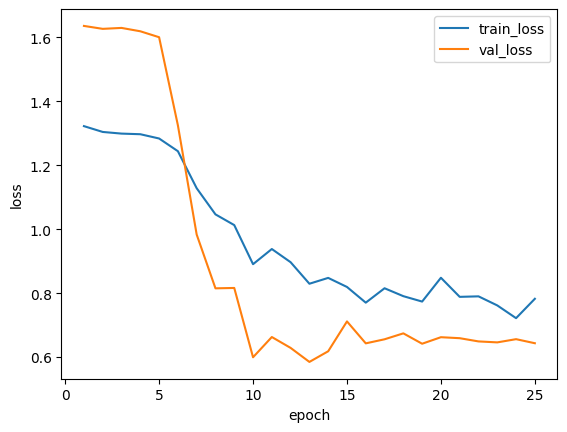

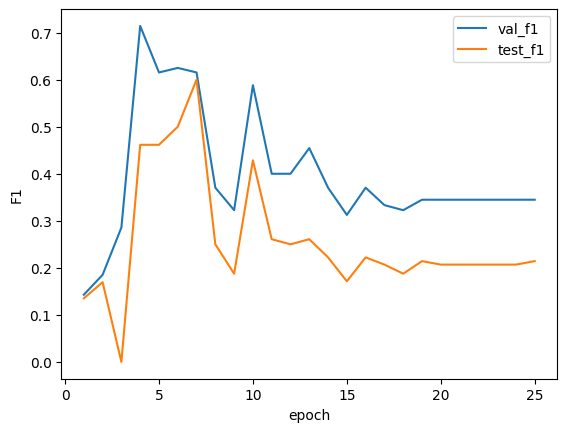

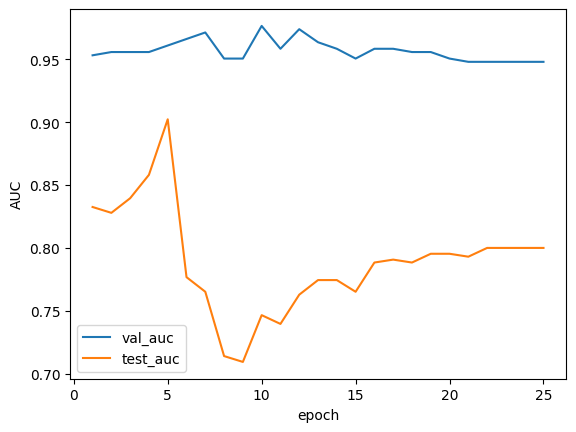

In [35]:
import matplotlib.pyplot as plt

epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, history["val_f1"], label="val_f1")
plt.plot(epochs, history["test_f1"], label="test_f1")
plt.xlabel("epoch")
plt.ylabel("F1")
plt.legend()
plt.show()

# AUC peut être None si une classe manque dans val/test
val_auc = [np.nan if v is None else v for v in history["val_auc"]]
test_auc = [np.nan if v is None else v for v in history["test_auc"]]

plt.figure()
plt.plot(epochs, val_auc, label="val_auc")
plt.plot(epochs, test_auc, label="test_auc")
plt.xlabel("epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()

In [ ]:
#Si val AUC/F1 baisse alors que train loss baisse → overfit → dropout↑ ou hidden↓.
#si tu overfit (train monte, val baisse) → baisse à 64
#si tu sous-apprends (train et val mauvais) → monte à 256

In [36]:
# Hyperparameters

PT_DIR = "embeddings_out"  
LABELS_PATH = "matrice_listantibio_final.cleaned.list"

SEED = 42
BATCH_SIZE = 8
EPOCHS = 25
LR = 3e-4
ATTN_DIM = 128
HIDDEN = 128
DROPOUT = 0.3

SPLIT = (0.8, 0.1, 0.1)  # train/val/test
#MAX_PROTEINS = 6000      # cut if needed

device = "cuda" if torch.cuda.is_available() else "cpu"


# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Loding Labels

def load_labels(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    df["Resistant"] = df["Resistant"].astype(int)
    df["Susceptible"] = df["Susceptible"].astype(int)

    bad = df[(df["Resistant"] + df["Susceptible"]) != 1]
    if len(bad) > 0:
        print("Incoherent label rows (Resistant+Susceptible != 1):", len(bad))
        print(bad.head())

    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"]))


# Load ONE .PT -> (genome_id, X(P,D))
a
def load_pt(fp):
    obj = torch.load(fp)
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X = obj["last_hidden_state"]

    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)

    # expected: (1,P,D) or (P,D)
    if X.ndim == 3:
        X = X.squeeze(0)
    if X.ndim != 2:
        raise ValueError(f"{fp}: unexpected last_hidden_state shape {tuple(X.shape)}")

    #if X.shape[0] > MAX_PROTEINS:
        #X = X[:MAX_PROTEINS]

    return gid, X.float()


# DATASET (1 genome = 1 item)

class GenomeMILDataset(Dataset):
    def __init__(self, pt_dir, id_to_y):
        self.id_to_y = id_to_y
        self.files = sorted(glob.glob(os.path.join(pt_dir, "*.pt")))
        if len(self.files) == 0:
            raise ValueError(f"No .pt found in: {pt_dir}")

        kept = []
        missing = 0
        for fp in self.files:
            gid, _ = load_pt(fp)
            if gid in id_to_y:
                kept.append(fp)
            else:
                missing += 1

        self.files = kept
        print("PT files with labels:", len(self.files), "| missing labels:", missing)
        if len(self.files) == 0:
            raise ValueError("No .pt matched to labels. Likely genome_id mismatch.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fp = self.files[idx]
        gid, X = load_pt(fp)  # (P,D)
        y = float(self.id_to_y[gid])  # 0/1
        return X, torch.tensor(y, dtype=torch.float32), gid


# COLLATE: PAD + MASK

def mil_collate(batch):
    xs, ys, gids = zip(*batch)
    lens = [x.shape[0] for x in xs]
    D = xs[0].shape[1]
    Pmax = max(lens)

    Xpad = torch.zeros((len(xs), Pmax, D), dtype=torch.float32)
    mask = torch.zeros((len(xs), Pmax), dtype=torch.float32)

    for i, x in enumerate(xs):
        P = x.shape[0]
        Xpad[i, :P] = x
        mask[i, :P] = 1.0

    y = torch.stack(list(ys), dim=0)  # (B,)
    return Xpad, mask, y, list(gids)


# GATED ATTENTION MIL MODEL

class GatedAttentionMIL(nn.Module):
    """
    X: (B,P,D), mask: (B,P)
    - computes attention weights alpha over proteins
    - pooled genome vector z = sum(alpha_i * x_i)
    - outputs genome logit (B,)
    """
    def __init__(self, emb_dim, attn_dim=128, hidden=128, dropout=0.2):
        super().__init__()
        self.drop = nn.Dropout(dropout)

        self.V = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Tanh())
        self.U = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Sigmoid())
        self.w = nn.Linear(attn_dim, 1)

        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, X, mask):
        X = self.drop(X)  # (B,P,D)
        A = self.w(self.V(X) * self.U(X)).squeeze(-1)  # (B,P)

        # ignore padding for softmax
        A = A.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(A, dim=1)  # (B,P)

        z = torch.sum(X * alpha.unsqueeze(-1), dim=1)  # (B,D)
        logit = self.classifier(z).squeeze(-1)         # (B,)
        return logit, alpha


# METRICS + TRAIN/EVAL LOOPS

def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = None
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_prob)
    return {"acc": acc, "f1": f1, "auc": auc}


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_y = []
    all_prob = []
    total_loss = 0.0
    n_batches = 0

    for Xpad, mask, y, _ in loader:
        Xpad = Xpad.to(device)
        mask = mask.to(device)
        y = y.to(device)

        logits, _ = model(Xpad, mask)
        loss = criterion(logits, y)

        prob = torch.sigmoid(logits).detach().cpu().numpy()
        all_prob.append(prob)
        all_y.append(y.detach().cpu().numpy())

        total_loss += float(loss.item())
        n_batches += 1

    y_true = np.concatenate(all_y, axis=0)
    y_prob = np.concatenate(all_prob, axis=0)
    m = compute_metrics(y_true, y_prob)
    m["loss"] = total_loss / max(n_batches, 1)
    return m


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for Xpad, mask, y, _ in loader:
        Xpad = Xpad.to(device)
        mask = mask.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits, _ = model(Xpad, mask)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        n_batches += 1

    return total_loss / max(n_batches, 1)


### MAIN ###

set_seed(SEED)

id_to_y = load_labels(LABELS_PATH)
dataset = GenomeMILDataset(PT_DIR, id_to_y)

# Split indices
n = len(dataset)
idx = np.random.permutation(n)

n_train = int(SPLIT[0] * n)
n_val = int(SPLIT[1] * n)
train_idx = idx[:n_train]
val_idx = idx[n_train:n_train + n_val]
test_idx = idx[n_train + n_val:]

train_ds = Subset(dataset, train_idx)
val_ds = Subset(dataset, val_idx)
test_ds = Subset(dataset, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=mil_collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mil_collate)

# emb_dim from one example
X0, _, _ = dataset[0]
emb_dim = X0.shape[1]
model = GatedAttentionMIL(emb_dim, attn_dim=ATTN_DIM, hidden=HIDDEN, dropout=DROPOUT).to(device)

# Handle imbalance (pos_weight)
all_labels = np.array([id_to_y[load_pt(fp)[0]] for fp in dataset.files], dtype=int)
pos = float(all_labels.sum())
neg = float(len(all_labels) - all_labels.sum())
pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
#optimizer = optim.Adam(model.parameters(), lr=LR)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

print("device:", device, "| emb_dim:", emb_dim)
print("train/val/test:", len(train_ds), len(val_ds), len(test_ds))
print("pos_weight:", float(pos_weight.item()))

best_val_auc = -1.0
best_state = None

history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": [],
    "val_f1": [],
    "test_auc": [],
    "test_f1": [],
}

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer)

    val_m = evaluate(model, val_loader) if len(val_ds) > 0 else {"auc": None, "f1": None, "acc": None, "loss": None}
    test_m = evaluate(model, test_loader)
    
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_m["loss"])
    history["val_auc"].append(val_m["auc"])
    history["val_f1"].append(val_m["f1"])
    history["test_auc"].append(test_m["auc"])
    history["test_f1"].append(test_m["f1"])

    # Select best on VAL AUC if possible, else on VAL F1
    score = val_m["auc"] if val_m["auc"] is not None else (val_m["f1"] if val_m["f1"] is not None else -1.0)
    if score > best_val_auc:
        best_val_auc = score
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | train_loss {tr_loss:.4f} | "
        f"val loss {val_m['loss']} acc {val_m['acc']} f1 {val_m['f1']} auc {val_m['auc']} | "
        f"test acc {test_m['acc']:.3f} f1 {test_m['f1']:.3f} auc {test_m['auc']}"
    )

# Restore best
if best_state is not None:
    model.load_state_dict(best_state)

#torch.save(model.state_dict(), "gated_attention_mil.pt")
#print("Saved: gated_attention_mil.pt")

final_test = evaluate(model, test_loader)
print("Final test metrics:", final_test)

PT files with labels: 907 | missing labels: 159
device: cuda | emb_dim: 480
train/val/test: 725 90 92
pos_weight: 16.11320686340332
Epoch 01 | train_loss 1.3046 | val loss 1.3431552449862163 acc 0.12222222222222222 f1 0.13186813186813187 auc 0.8531746031746031 | test acc 0.087 f1 0.106 auc 0.8528735632183907
Epoch 02 | train_loss 1.3053 | val loss 1.3399967749913533 acc 0.9333333333333333 f1 0.0 auc 0.875 | test acc 0.935 f1 0.000 auc 0.8620689655172413
Epoch 03 | train_loss 1.2908 | val loss 1.3344094256560008 acc 0.9222222222222223 f1 0.5882352941176471 auc 0.8908730158730158 | test acc 0.891 f1 0.375 auc 0.8735632183908046
Epoch 04 | train_loss 1.2793 | val loss 1.330462137858073 acc 0.9333333333333333 f1 0.0 auc 0.8968253968253969 | test acc 0.946 f1 0.000 auc 0.871264367816092
Epoch 05 | train_loss 1.2927 | val loss 1.3088123053312302 acc 0.5888888888888889 f1 0.24489795918367346 auc 0.9107142857142858 | test acc 0.391 f1 0.152 auc 0.8758620689655172
Epoch 06 | train_loss 1.2553 |

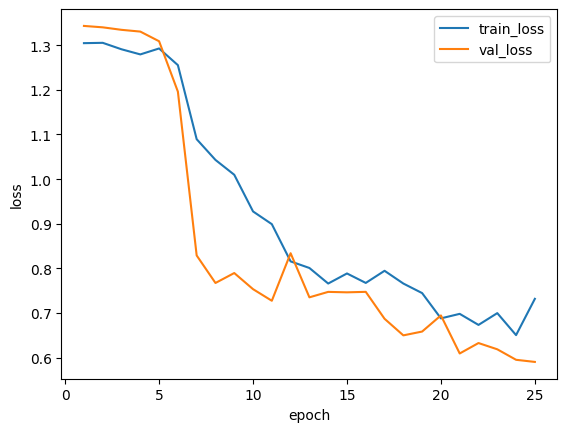

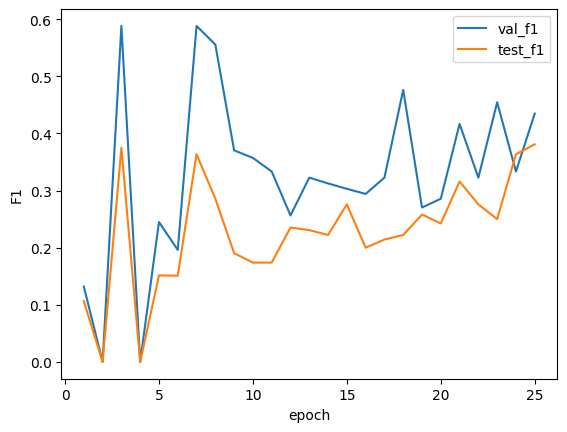

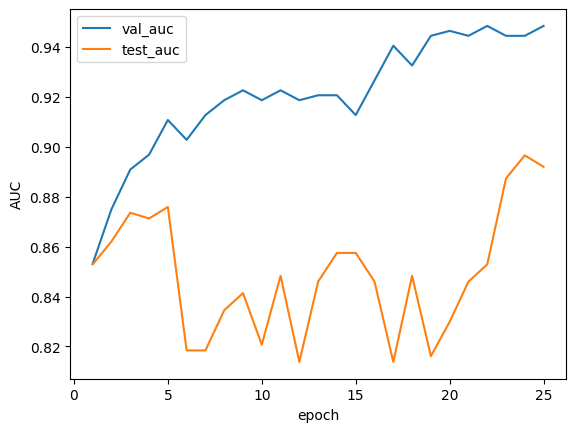

In [37]:
import matplotlib.pyplot as plt

epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, history["val_f1"], label="val_f1")
plt.plot(epochs, history["test_f1"], label="test_f1")
plt.xlabel("epoch")
plt.ylabel("F1")
plt.legend()
plt.show()

# AUC peut être None si une classe manque dans val/test
val_auc = [np.nan if v is None else v for v in history["val_auc"]]
test_auc = [np.nan if v is None else v for v in history["test_auc"]]

plt.figure()
plt.plot(epochs, val_auc, label="val_auc")
plt.plot(epochs, test_auc, label="test_auc")
plt.xlabel("epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()